In [22]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [23]:
path_cwd = pathlib.Path.cwd()
input_dataset_path = pathlib.Path(path_cwd,"..", "data_processed", "df_final_1.csv")
df_final = pd.read_csv(input_dataset_path)

In [24]:
df_final.head()

,TIME_PERIOD,OBS_VALUE,Comune,Popolazione residente,Superficie (Kmq),Road_accident_per_resident,Road_accident_per_Kmq,Densità_della_popolazione
0,2001,5,Agliè,2545.0,13.1462,0.001965,0.380338,193.592065
1,2002,5,Agliè,2545.0,13.1462,0.001965,0.380338,193.592065
2,2003,4,Agliè,2545.0,13.1462,0.001572,0.304270,193.592065
3,2004,9,Agliè,2545.0,13.1462,0.003536,0.684608,193.592065
4,2005,2,Agliè,2545.0,13.1462,0.000786,0.152135,193.592065


In [25]:
input_dataframe = df_final[
    [
        'Densità_della_popolazione',
        'Road_accident_per_Kmq'
    ]
]

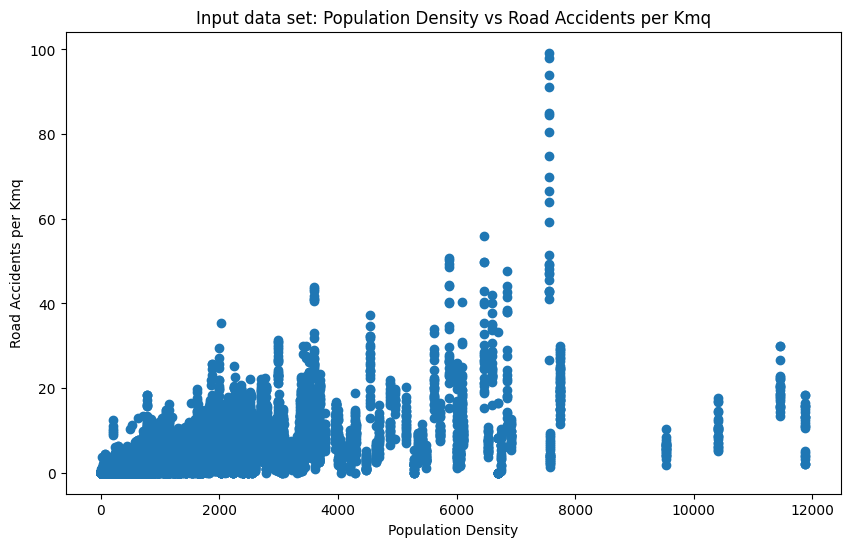

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df_final["Densità_della_popolazione"], df_final["Road_accident_per_Kmq"], marker="o")
plt.title('Input data set: Population Density vs Road Accidents per Kmq')
plt.xlabel('Population Density')
plt.ylabel('Road Accidents per Kmq')

# Show the plot
plt.show()

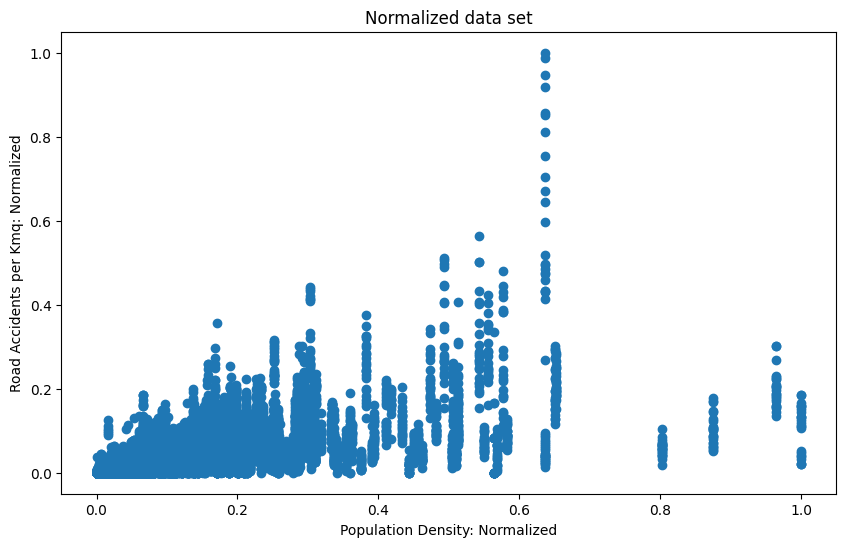

In [27]:
scale_norm = MinMaxScaler()
scaled_dataframe = pd.DataFrame(
    scale_norm.fit_transform(input_dataframe),
    columns=input_dataframe.columns)

plt.figure(figsize=(10, 6))
plt.scatter(
    scaled_dataframe["Densità_della_popolazione"], scaled_dataframe["Road_accident_per_Kmq"], marker="o")
plt.title('Normalized data set')
plt.xlabel('Population Density: Normalized')
plt.ylabel('Road Accidents per Kmq: Normalized')

plt.show()

Using MinMaxScaler both variables are trasformed in the same range

In [28]:
scaled_dataframe.dtypes

Densità_della_popolazione    float64
Road_accident_per_Kmq        float64
dtype: object

In [29]:
scaled_dataframe.head()

,Densità_della_popolazione,Road_accident_per_Kmq
0,0.016223,0.003833
1,0.016223,0.003833
2,0.016223,0.003067
3,0.016223,0.006900
4,0.016223,0.001533


In [30]:
scaled_dataframe.isnull().sum()

Densità_della_popolazione    0
Road_accident_per_Kmq        0
dtype: int64

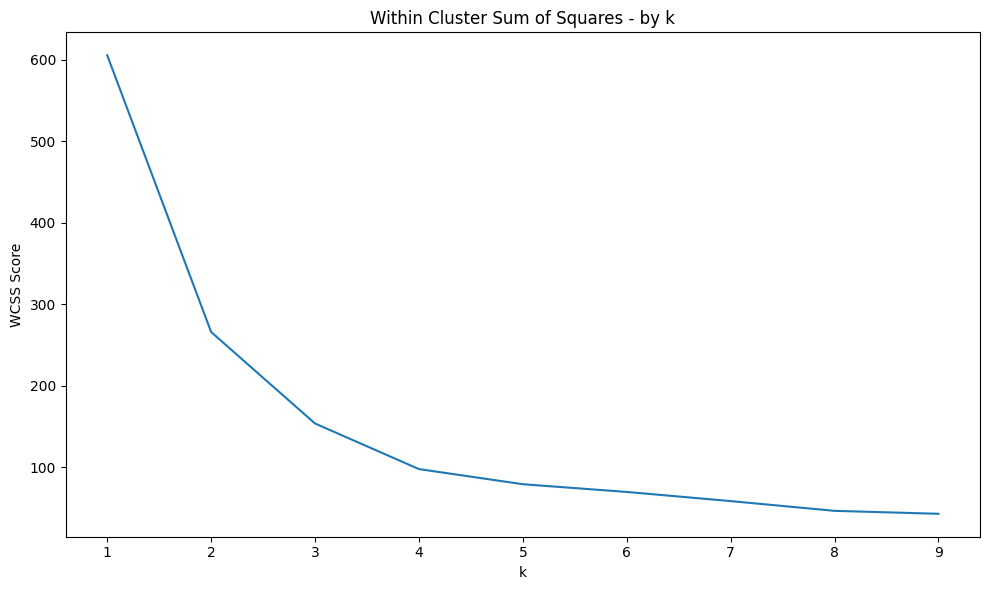

In [31]:
# Use WCSS to find a good value k
k_values = list(range(1, 10))
wcss_list = []

for k in k_values:
	kmeans = KMeans(n_clusters=k, random_state=42)
	kmeans.fit(scaled_dataframe)
	wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss_list)
plt.title("Within Cluster Sum of Squares - by k")
plt.xlabel("k")
plt.ylabel("WCSS Score")
plt.tight_layout()
plt.show()

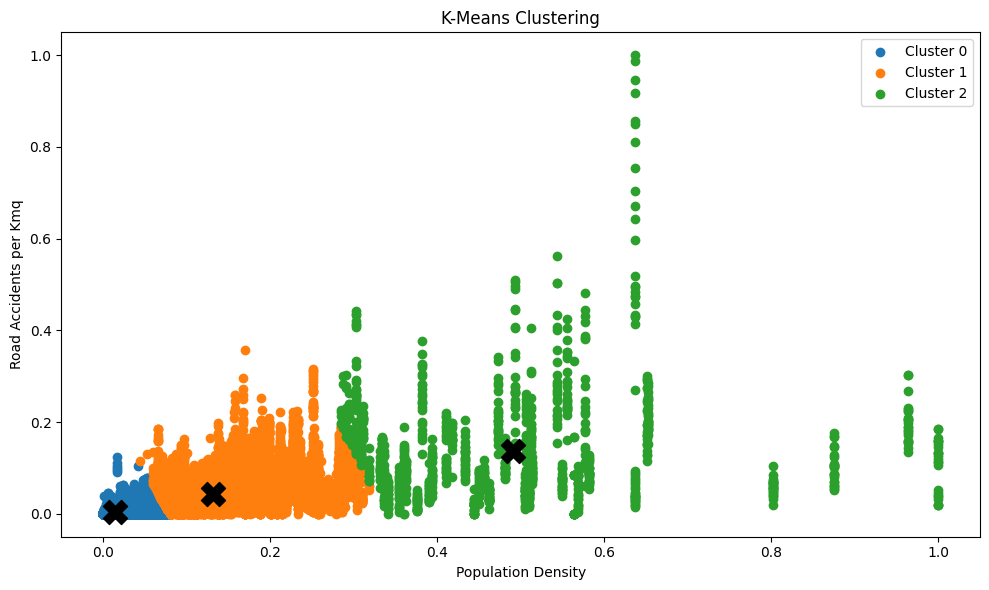

In [32]:
k = 3  # the elbow plot suggests that 3 is a good value for k because the WCSS score starts to level off after this point.
# Instantiate and fit the KMeans model
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(
    scaled_dataframe[["Densità_della_popolazione", "Road_accident_per_Kmq"]])

# Add the cluster labels to the DataFrame
scaled_dataframe["cluster"] = kmeans.labels_

# Plot the clusters and centroids
centroids = kmeans.cluster_centers_
clusters = scaled_dataframe.groupby("cluster")
plt.figure(figsize=(10, 6))
for cluster, data in clusters:
    plt.scatter(
        data["Densità_della_popolazione"], data["Road_accident_per_Kmq"], marker="o", label=f'Cluster {cluster}')
    plt.scatter(
        centroids[cluster, 0], centroids[cluster, 1], marker="X", color="black", s=300)

plt.xlabel("Population Density")
plt.ylabel("Road Accidents per Kmq")
plt.title("K-Means Clustering")
plt.legend()
plt.tight_layout()
plt.show()

CONCLUSION

The Elbow Method identified 3 as the optimal number of clusters for the K-Means algorithm. Italian municipalities were grouped into three different clusters with similar characteristics based on population density and road accidents per kmq. 

The resulting clusters highlight different municipality profiles, showing that road accident concentration is not evenly distributed across the territory. Municipalities with similar population density tend to exhibit similar accident rates per Kmq, allowing the identification of groups with comparable characteristics.

The clustering analysis provides a useful segmentation of municipalities and helps reveal patterns in the relationship betweem population density and road accident concentration